In [10]:
import pandas as pd

# Load the file
df = pd.read_csv('OneDrive/Documents/Custom Office Templates/E-Commerce Sales Performance Project/E_Commerce.csv')

# View the first 5 rows
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,01-01-2023,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,01-01-2023,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,01-01-2023,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,01-01-2023,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,01-01-2023,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


C:\Users\saila\AppData\Local\Temp\ipykernel_83732\1790442574.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('Date').resample('M')['Total_Amount'].sum()


<Axes: title={'center': 'Total Monthly Revenue'}, xlabel='Date'>

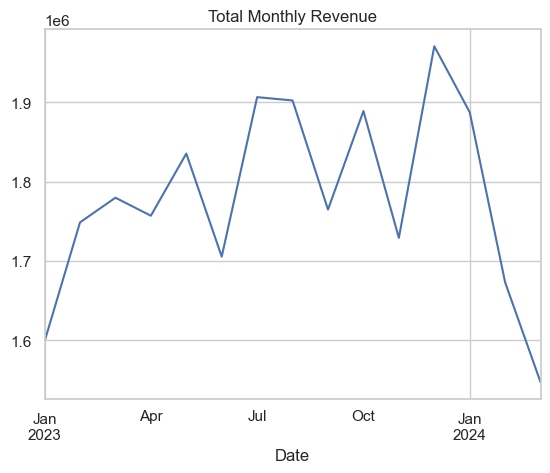

In [11]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Group by month to see trends
monthly_sales = df.set_index('Date').resample('M')['Total_Amount'].sum()
monthly_sales.plot(title='Total Monthly Revenue')

In [12]:
category_perf = df.groupby('Product_Category').agg({'Total_Amount': 'sum', 'Quantity': 'sum'})
category_perf.sort_values(by='Total_Amount', ascending=False)

,Total_Amount,Quantity
Product_Category,,
Electronics,12810704.46,7656
Home & Garden,4932252.80,7508
Sports,3959650.55,8375
Fashion,1952250.63,7489
Toys,1237380.01,7671
Beauty,851021.76,7988
Food,518193.32,7736
Books,433143.63,8018


<Axes: title={'center': 'Average Spend by Gender'}, xlabel='Gender'>

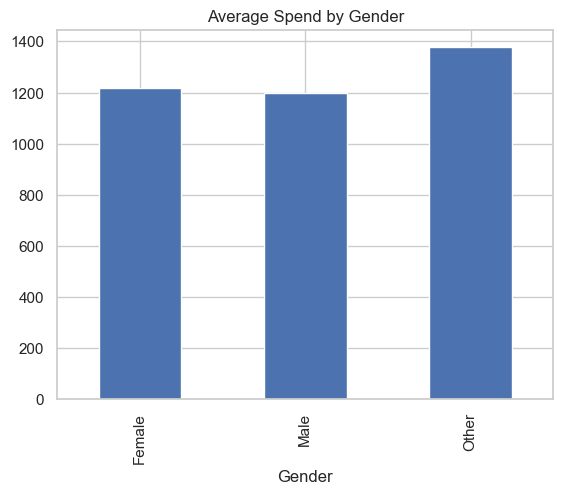

In [13]:
# Sales by Gender
df.groupby('Gender')['Total_Amount'].mean().plot(kind='bar', title='Average Spend by Gender')

In [14]:
# Check correlation between delivery time and rating
correlation = df[['Delivery_Time_Days', 'Customer_Rating']].corr()
print(correlation)

                    Delivery_Time_Days  Customer_Rating
Delivery_Time_Days            1.000000        -0.008812
Customer_Rating              -0.008812         1.000000


In [15]:
df.groupby('Device_Type')[['Session_Duration_Minutes', 'Pages_Viewed']].mean()

,Session_Duration_Minutes,Pages_Viewed
Device_Type,,
Desktop,14.620302,8.960826
Mobile,14.485087,9.004539
Tablet,14.615777,9.099304


In [16]:
import datetime as dt

# 1. Set a reference date (the day after the last order in your data)
snapshot_date = df['Date'].max() + dt.timedelta(days=1)

# 2. Calculate RFM values per customer
rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                             # Frequency
    'Total_Amount': 'sum'                            # Monetary
})

# 3. Rename columns for clarity
rfm.rename(columns={'Date': 'Recency', 'Order_ID': 'Frequency', 'Total_Amount': 'Monetary'}, inplace=True)

# 4. Create Scores (1 to 4) - Higher is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]) # Lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# 5. Calculate total RFM Score
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# 6. Define Segments
def segment_customer(row):
    if row['RFM_Total'] >= 9:
        return 'Champions'
    elif row['RFM_Total'] >= 5:
        return 'Loyal Customers'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Check the results!
print(rfm['Segment'].value_counts())

Segment
Loyal Customers    2469
Champions          1865
At Risk             666
Name: count, dtype: int64


<Axes: xlabel='Day_of_Week'>

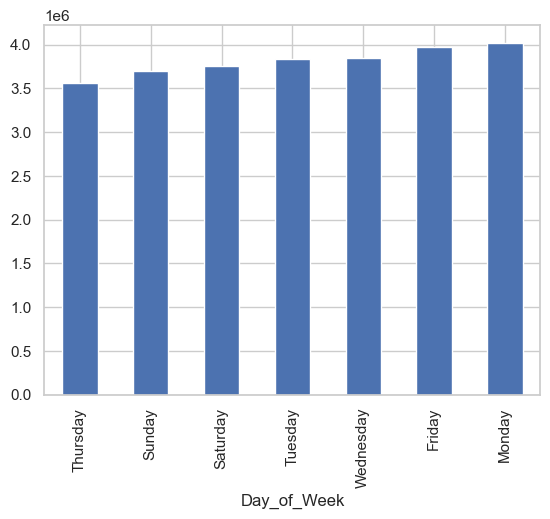

In [17]:
# Example code to add these columns
df['Day_of_Week'] = df['Date'].dt.day_name()
df.groupby('Day_of_Week')['Total_Amount'].sum().sort_values().plot(kind='bar')

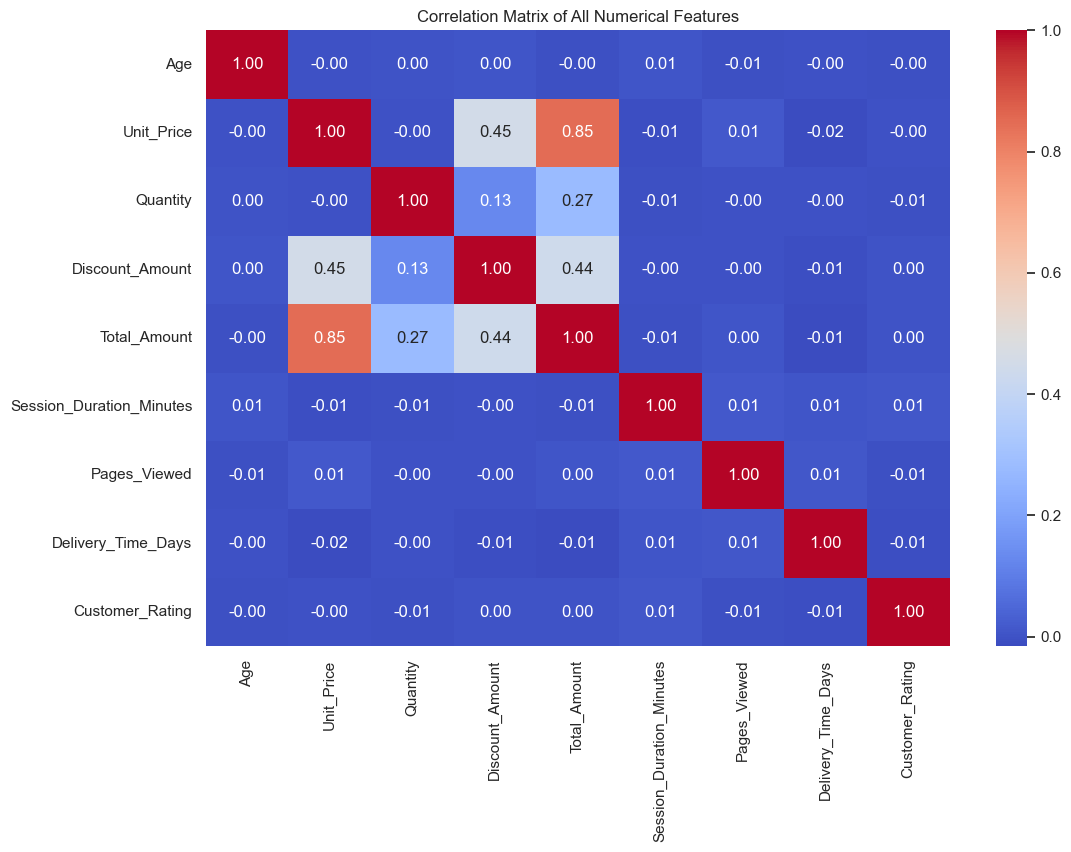

In [18]:
# Copy and run this to see the "Big Picture"
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of All Numerical Features')
plt.show()

C:\Users\saila\AppData\Local\Temp\ipykernel_83732\884711284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', palette='magma', order=['Champions', 'Loyal Customers', 'At Risk'])


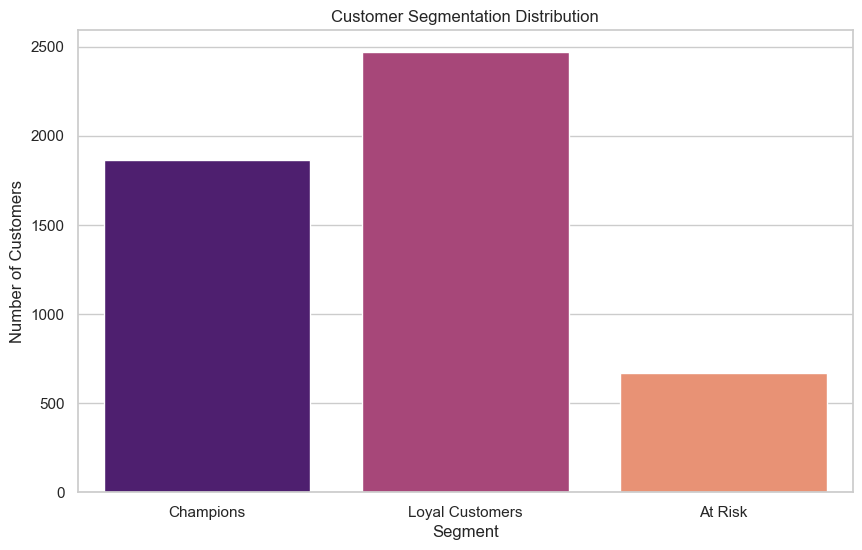

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', palette='magma', order=['Champions', 'Loyal Customers', 'At Risk'])
plt.title('Customer Segmentation Distribution')
plt.ylabel('Number of Customers')
plt.show()